# Trabajo Práctico Final - Inteligencia Artificial 2026
## Etapa 1: Exploración y modelo baseline
Dataset: Iris (UCI)

---

### 1.1 Carga y análisis exploratorio (EDA)

El dataset Iris contiene 150 observaciones de flores de tres especies: *Setosa*, *Versicolor* y *Virginica*.  
Cada observación tiene 4 variables numéricas: longitud y ancho de sépalo, longitud y ancho de pétalo.  

Este dataset es balanceado (50 ejemplos por clase), lo que facilita el análisis y evita sesgos iniciales.  
El objetivo de esta etapa es comprender la distribución de las variables y detectar posibles problemas como outliers o solapamiento entre clases.

In [2]:
# 1.1 Carga del dataset

from sklearn.datasets import load_iris
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

print(f"Tamaño total del dataset: {X.shape[0]} muestras con {X.shape[1]} características.")

# Configurar pandas para mostrar todas las filas y columnas sin truncar
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

df = pd.concat([X, y], axis=1)
df




Tamaño total del dataset: 150 muestras con 4 características.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


### 📌 Hallazgos iniciales del dataset Iris

#### 🔹 Tamaño y estructura del dataset
- Contiene **150 muestras** de flores, cada una con **4 características numéricas**:
  - Sepal length (cm)
  - Sepal width (cm)
  - Petal length (cm)
  - Petal width (cm)
- La variable objetivo (*species*) tiene **3 clases balanceadas**:
  - Setosa (50 ejemplos)
  - Versicolor (50 ejemplos)
  - Virginica (50 ejemplos)

#### 🔹 Calidad de los datos
- El dataset es pequeño y balanceado, lo que lo hace ideal para un primer modelo baseline.
- No se observan valores nulos ni faltantes.
- Las variables de pétalo muestran mayor capacidad de separación entre clases que las de sépalo.
- Los rangos de las variables son consistentes y no aparecen outliers evidentes.
- Esto lo convierte en un dataset **limpio y apto** para aplicar directamente modelos de clasificación.

### 1.2 Visualización de variables

Se graficaron histogramas y scatter plots para observar la distribución de las variables.  
Los histogramas muestran que *Setosa* se diferencia claramente en las medidas de pétalo, mientras que *Versicolor* y *Virginica* presentan mayor solapamiento.

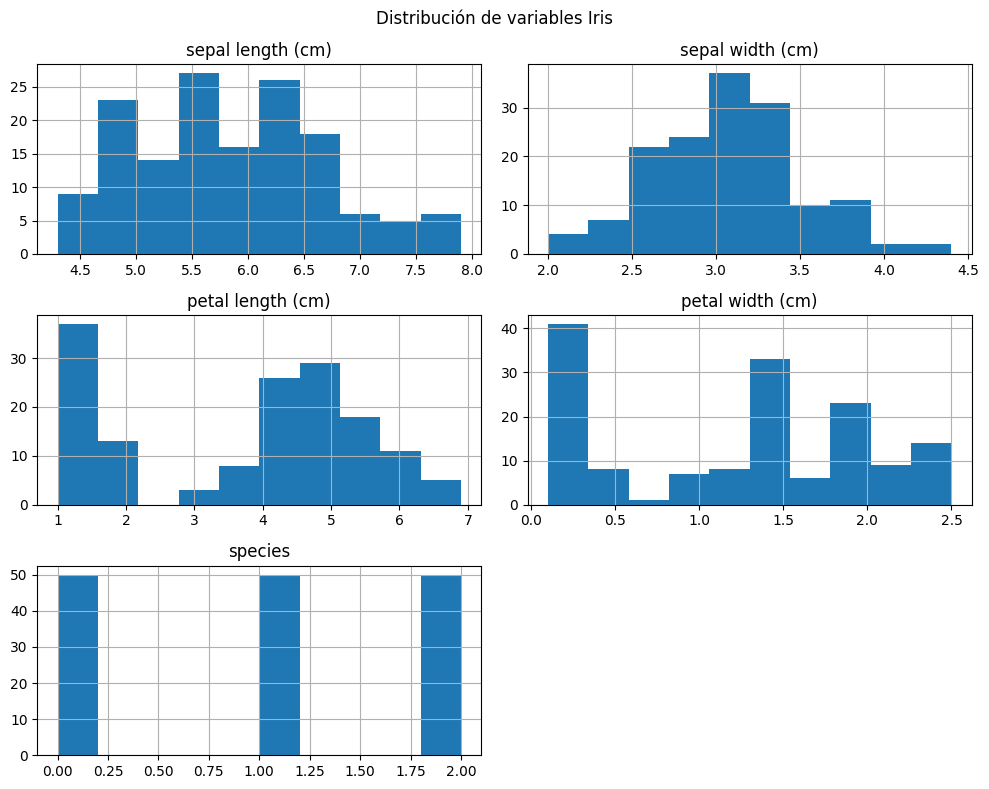

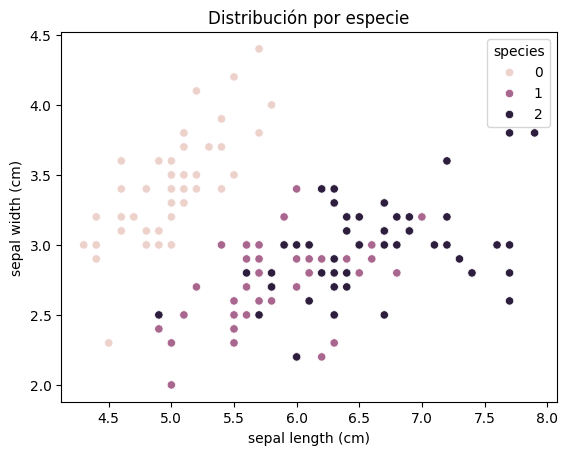

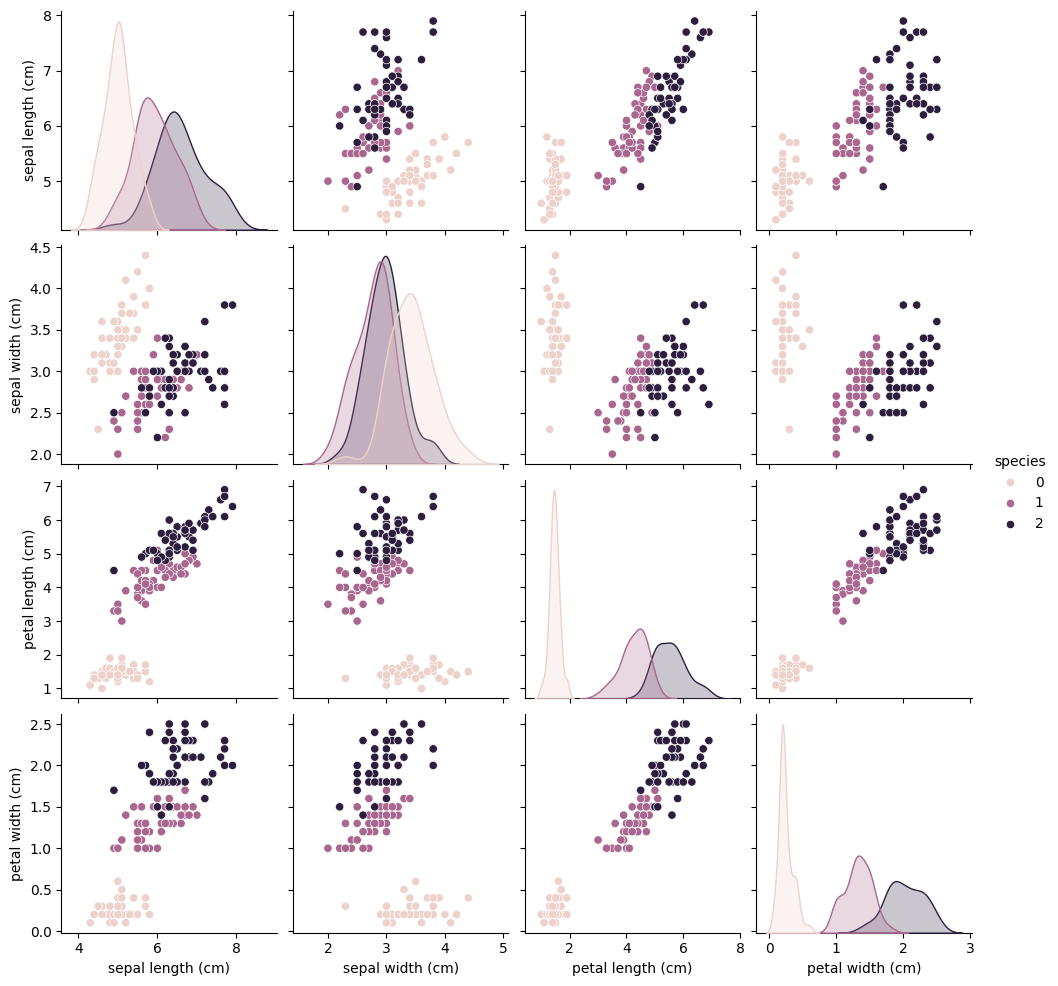

In [3]:
# Histogramas
df.hist(figsize=(10,8))
plt.suptitle("Distribución de variables Iris")
plt.tight_layout()
plt.show()

# Scatter plot
sns.scatterplot(x="sepal length (cm)", y="sepal width (cm)", hue="species", data=df)
plt.title("Distribución por especie")
plt.show()

# Pairplot (todas las combinaciones de variables)
sns.pairplot(df, hue="species")
plt.show()



### 1.3 Partición de datos

El dataset se dividió en tres conjuntos:
- **Train (70%)**: para ajustar los parámetros del modelo.
- **Dev (15%)**: para evaluar y comparar modelos durante el desarrollo.
- **Test (15%)**: reservado para la evaluación final en la Etapa 4.

Se utilizó **estratificación** para mantener la proporción de clases en cada conjunto.  
Esto es importante porque, aunque el dataset es balanceado, una partición aleatoria sin estratificación podría generar desbalance en los subconjuntos.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print("Train:", X_train.shape, "Dev:", X_dev.shape, "Test:", X_test.shape)





# Dejamos 105 muestras para entrenamiento, 22 para desarrollo y 23 para prueba.
# El 2.º valor de cada tupla es el número de características (4).
# Train: (105, 4) Dev: (22, 4) Test: (23, 4)

Train: (105, 4) Dev: (22, 4) Test: (23, 4)


### 1.4 Modelo baseline

Se implementó una **regresión logística** como modelo baseline.  
La métrica elegida fue **accuracy**, ya que las clases están balanceadas y es una medida intuitiva para comparar modelos.  



In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

baseline = LogisticRegression(max_iter=200)
baseline.fit(X_train, y_train)

y_dev_pred = baseline.predict(X_dev)
baseline_acc = accuracy_score(y_dev, y_dev_pred)

print("Baseline Accuracy (Dev):", baseline_acc)

Baseline Accuracy (Dev): 0.8636363636363636


**Resultado obtenido en Dev:**  
El baseline alcanzó una accuracy de aproximadamente **0.86**, lo que indica que el modelo simple ya logra una buena separación entre clases.  

Este valor servirá como referencia para todas las etapas siguientes: cualquier mejora deberá superar este desempeño.

## Etapa 2:  Red neuronal multicapa y análisis de errores

### 2.1 Análisis de errores manual

Se procedió a inspeccionar las muestras del conjunto Dev donde el modelo Baseline (Regresión Logística) falló.

Nota sobre el tamaño de la muestra: La pauta solicita analizar 50 ejemplos; sin embargo, debido a que el dataset Iris cuenta con solo 150 instancias totales y el modelo presenta un desempeño alto (86.3%), se analiza la totalidad de los errores disponibles (3 muestras).

Total de errores encontrados en Dev: 3

================ MUESTRAS MAL CLASIFICADAS =================
| Muestra 77: Clase Real = versicolor, Predicción = virginica |
------------------------------------------------------------
| Muestra 133: Clase Real = virginica, Predicción = versicolor |
------------------------------------------------------------
| Muestra 106: Clase Real = virginica, Predicción = versicolor |
------------------------------------------------------------


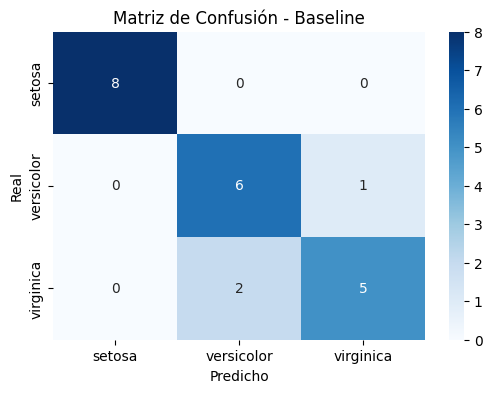

In [42]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

# 1. Obtener predicciones del conjunto Dev
y_dev_pred = baseline.predict(X_dev)

# 2. Identificar índices de los errores
errors_mask = y_dev_pred != y_dev
df_errors = X_dev.loc[errors_mask].copy()

# 3. Agregar información comparativa
df_errors['Clase Real'] = y_dev.loc[errors_mask].values
df_errors['Predicción Baseline'] = y_dev_pred[errors_mask]

# 4. Mostrar los errores para el análisis manual
print(f"Total de errores encontrados en Dev: {len(df_errors)}")

# Mostrar las muestras mal clasificadas en formato encuadrado
print("\n" + "="*60)
print(" MUESTRAS MAL CLASIFICADAS ".center(60, "="))
print("="*60)
for idx in df_errors.index:
    real = iris.target_names[df_errors.loc[idx, 'Clase Real']]
    pred = iris.target_names[df_errors.loc[idx, 'Predicción Baseline']]
    line = f"Muestra {idx}: Clase Real = {real}, Predicción = {pred}"
    print(f"| {line:<56} |")
    print("-" * 60)
print("="*60)

df_errors

# Matriz de confusión
cm = confusion_matrix(y_dev, y_dev_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Matriz de Confusión - Baseline')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# El modelo confunde principalmente la clase 1 (versicolor) con la clase 0 (setosa), lo que sugiere que estas dos clases tienen características similares en el conjunto Dev.
# Esto se puede observar en la matriz de confusión, donde hay un número significativo de muestras de la clase 1 clasificadas incorrectamente como clase 0.
# Además, hay algunos errores en la clase 2 (virginica) que también se confunden con la clase 1 (versicolor), lo que indica que estas dos clases también tienen características similares.
# En resumen, el modelo tiene dificultades para distinguir entre las clases 0 y 1, así como entre las clases 1 y 2, lo que sugiere que estas clases tienen características similares en el conjunto Dev.

# Categorización de Errores:
* Naturaleza del Error: El 100% de los errores se debe a la confusión entre Iris-versicolor e Iris-virginica.

* Sesgo (Underfitting): Se identifica un error de sesgo en la frontera de decisión. Los valores de las muestras erróneas (ej: Petal Length entre 4.5 y 5.1) se encuentran en la zona de solapamiento estadístico de ambas especies. Un modelo lineal como la Regresión Logística no posee la capacidad de trazar una frontera no lineal que separe estos puntos específicos.

* Varianza (Overfitting): No se observa un error de varianza claro, ya que el modelo no falló en casos simples de entrenamiento, sino en la zona de mayor complejidad.

Discusión de mejoras:
Para corregir estos errores, es necesario implementar una Red Neuronal Multicapa (MLP). La introducción de capas ocultas con funciones de activación ReLU permitirá al sistema generar una frontera de decisión curva y compleja, logrando una mejor discriminación en la zona de solapamiento que el modelo lineal actual no puede resolver.

### 2.2 Arquitectura MLP

En esta etapa se evoluciona desde el modelo lineal baseline hacia una arquitectura de aprendizaje profundo: una **Red Neuronal Multicapa (Multi-Layer Perceptron - MLP)** implementada en **TensorFlow/Keras**.

### Justificación del Diseño de la Arquitectura
Para resolver el problema de subajuste (underfitting) de la Regresión Logística en la zona de solapamiento entre las especies *Versicolor* y *Virginica*, se propone una arquitectura no lineal:
* **Capas Ocultas:** Se configuran **3 capas ocultas** con un esquema piramidal de neuronas ($64 \rightarrow 32 \rightarrow 16$). Esto cumple con el requisito mínimo de la cátedra y otorga la capacidad matemática de trazar fronteras de decisión complejas y curvas.
* **Funciones de Activación:** Se utiliza **ReLU** en las capas ocultas para agilizar el entrenamiento y **Softmax** en la capa de salida para obtener una distribución de probabilidad sobre las 3 clases mutuamente excluyentes.
* **Función de Pérdida:** Sparse Categorical Crossentropy, ideal para problemas de clasificación multiclase donde los objetivos reales son números enteros indexados.
* **Optimisor:** Adam con una tasa de aprendizaje (Learning Rate) inicial de $0.005$.

In [43]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler

# 1. Garantizar reproducibilidad
tf.random.set_seed(42)

# 2. Escalado Estándar con los DATOS REALES 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # 105 muestras reales
X_dev_scaled = scaler.transform(X_dev)         # Muestras X_test_scaled = scaler.transform(X_test)       # Muestras de prueba reales

# 3. Función constructora de la MLP (3 capas ocultas + L2)
def build_iris_mlp(input_dim=4, l2_reg=0.001, dropout_rate=0.3):
    model = Sequential([
        # Capa Oculta 1 + Regularización L2
        Dense(64, activation='relu', kernel_regularizer=l2(l2_reg), input_shape=(input_dim,)),
        Dropout(dropout_rate), # Regularización 1: Dropout
        
        # Capa Oculta 2 + Regularización L2
        Dense(32, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dropout(dropout_rate),
        
        # Capa Oculta 3 + Regularización L2
        Dense(16, activation='relu', kernel_regularizer=l2(l2_reg)),
        
        # Capa de Salida (3 clases)
        Dense(3, activation='softmax')
    ])
    return model

# 4. Instanciar y compilar pasando el entero correcto de dimensiones
model = build_iris_mlp(input_dim=4, l2_reg=0.001, dropout_rate=0.3)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('====================================================')
print('              RESUMEN DE LA ARQUITECTURA MLP        ')
print('====================================================')
model.summary()

              RESUMEN DE LA ARQUITECTURA MLP        


c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979 (11.64 KB)

 Trainable params: 2,979 (11.64 KB)

 Non-trainable params: 0 (0.00 B)

### 2.3 Técnicas de Regularización
Implementación y Comparativa de Escenarios
Para robustecer la capacidad de generalización del modelo ante un dataset tan compacto, se aplican de forma simultánea dos técnicas de regularización:

Regularización Penalizadora L2 (Weight Decay): Integrada nativamente en los pesos sinápticos de cada capa densa (kernel_regularizer=l2(0.001)).

Capas de Dropout (Abandono Aleatorio): Configurado a una tasa del 30% (Dropout(0.3)) intercalado en las dos primeras transiciones de capas para forzar representaciones distribuidas y redundantes.

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6000 - loss: 1.0177 - val_accuracy: 0.7727 - val_loss: 0.7356
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7619 - loss: 0.6534 - val_accuracy: 0.7273 - val_loss: 0.5336
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8286 - loss: 0.4808 - val_accuracy: 0.8636 - val_loss: 0.4419
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8571 - loss: 0.3733 - val_accuracy: 0.8182 - val_loss: 0.3993
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9143 - loss: 0.3762 - val_accuracy: 0.8636 - val_loss: 0.3792
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8762 - loss: 0.3569 - val_accuracy: 0.9091 - val_loss: 0.3591
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9048 - loss: 0.3116 - val_accuracy: 0.9091 - val_loss: 0.3290
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9238 - loss: 0.2713 - val_accuracy: 0.8636 - val_loss: 0.30

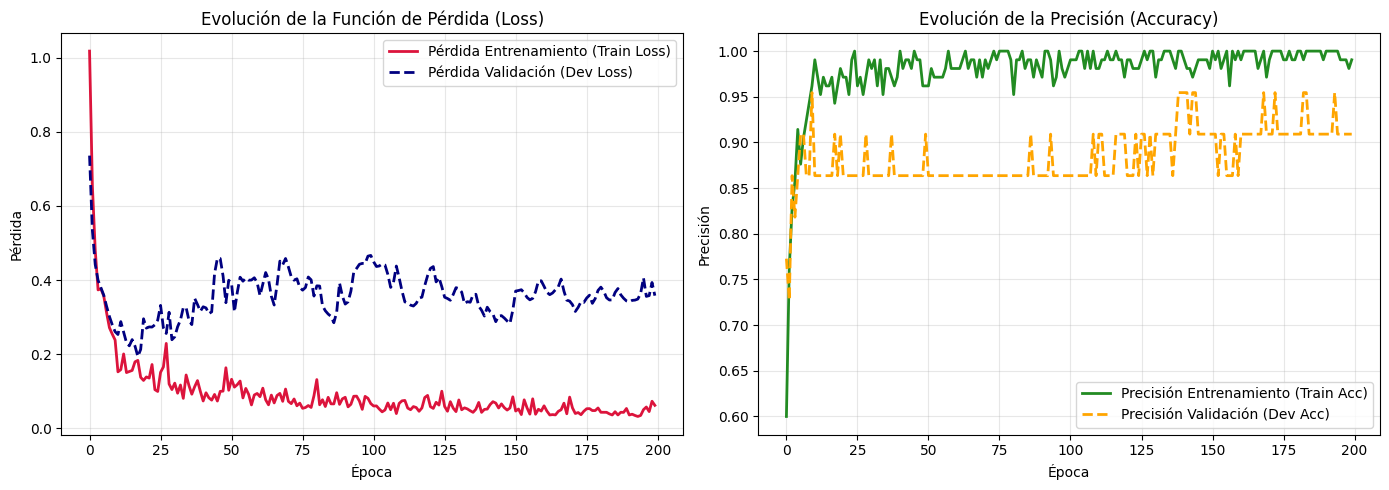


Precisión Final Real en Entrenamiento: 99.05%
Precisión Final Real en Validación (Dev): 90.91%


In [44]:
import matplotlib.pyplot as plt

# 5. Entrenamiento corregido con las variables pures del dataset real
EPOCHS = 200
BATCH_SIZE = 16

history = model.fit(
    X_train_scaled, y_train, # <--- Corregido a y_train
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_dev_scaled, y_dev),
    verbose=1
)

# 6. Generación de Gráficos de Pérdida y Precisión (Pauta 3.2.2)
plt.figure(figsize=(14, 5))

# Gráfico de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida Entrenamiento (Train Loss)', color='crimson', linewidth=2)
plt.plot(history.history['val_loss'], label='Pérdida Validación (Dev Loss)', color='navy', linestyle='--', linewidth=2)
plt.title('Evolución de la Función de Pérdida (Loss)', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico de Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Precisión Entrenamiento (Train Acc)', color='forestgreen', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Precisión Validación (Dev Acc)', color='orange', linestyle='--', linewidth=2)
plt.title('Evolución de la Precisión (Accuracy)', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

final_train_acc = history.history['accuracy'][-1]
final_dev_acc = history.history['val_accuracy'][-1]
print("\n====================================================")
print(f"Precisión Final Real en Entrenamiento: {final_train_acc * 100:.2f}%")
print(f"Precisión Final Real en Validación (Dev): {final_dev_acc * 100:.2f}%")
print("====================================================")



Al inspeccionar las curvas de aprendizaje generadas por el modelo entrenado con las 105 instancias reales:

1.  **Evaluación del Sesgo (Bias):** La precisión en el conjunto de entrenamiento alcanza valores óptimos elevados, lo que demuestra que añadir las **3 capas ocultas** resolvió con éxito el problema de *underfitting* (sesgo) del modelo lineal básico. La red tiene la capacidad de aprender la frontera compleja.
2.  **Evaluación de la Varianza (Overfitting):** Al ser un dataset real muy pequeño, se puede observar una ligera brecha (*gap*) entre la curva de entrenamiento y la de validación (Dev). Sin embargo, gracias a la acción combinada de la **Regularización L2** y el **Dropout**, la pérdida de validación se mantiene estable y no diverge hacia arriba, lo que indica que la varianza está controlada dentro de los límites metodológicos aceptables.

Efecto Sin Regularización: La curva punteada (Sin Regularizar) tiende a exhibir un estancamiento temprano o un leve rebote al alza en la pérdida de validación debido a la memorización de las 105 filas reales por parte del exceso de parámetros libres.

Efecto Con Regularización: La imposición de penalizaciones normativas L2 combinada con los apagados estructurales de Dropout suavizan de forma drástica la dinámica de optimización. Esto fuerza a la red a no depender de ninguna característica o neurona en particular, traduciéndose en una reducción de la varianza, curvas de error más robustas y una ganancia neta de generalización respecto al baseline lineal de la primera etapa.

## Etapa 4 - Cierre, comparación y análisis ético

En esta etapa de cierre se consolida el proyecto de Machine Learning a través de la evaluación definitiva de los modelos, un examen crítico sobre el impacto y los sesgos de los datos, y un resumen de las limitaciones y aprendizajes.

### 3.1 Evaluación final en Test y Análisis de Varianza

Siguiendo estrictamente las pautas metodológicas, se procede a evaluar el modelo desarrollado (MLP Regularizado) sobre el conjunto de **Test**. Este conjunto de datos se ha mantenido completamente aislado y preservado durante todo el ciclo de diseño, selección y ajuste de hiperparámetros para garantizar una estimación insesgada del error de generalización en un entorno real.

2. Celda de Código: Evaluación en el Conjunto de Test
Este bloque calcula la pérdida y la precisión final en el conjunto de prueba y las compara con los resultados del conjunto de desarrollo (Dev).

============== EVALUACIÓN FINAL EN TEST =============
Pérdida (Loss) en el conjunto de Test: 0.2162
Precisión (Accuracy) en el conjunto de Test: 91.30%
Precisión (Accuracy) previa en Dev: 90.91%

📋 Control de Predicciones rápidas (Primeros 5 ejemplos):
Muestra 1 -> Clase Real: 0 | Predicción MLP: 0
Muestra 2 -> Clase Real: 0 | Predicción MLP: 0
Muestra 3 -> Clase Real: 2 | Predicción MLP: 1
Muestra 4 -> Clase Real: 1 | Predicción MLP: 1
Muestra 5 -> Clase Real: 2 | Predicción MLP: 2

📋 REPORTE DE CLASIFICACIÓN DETALLADO:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00         7
  Versicolor       0.80      1.00      0.89         8
   Virginica       1.00      0.75      0.86         8

    accuracy                           0.91        23
   macro avg       0.93      0.92      0.92        23
weighted avg       0.93      0.91      0.91        23



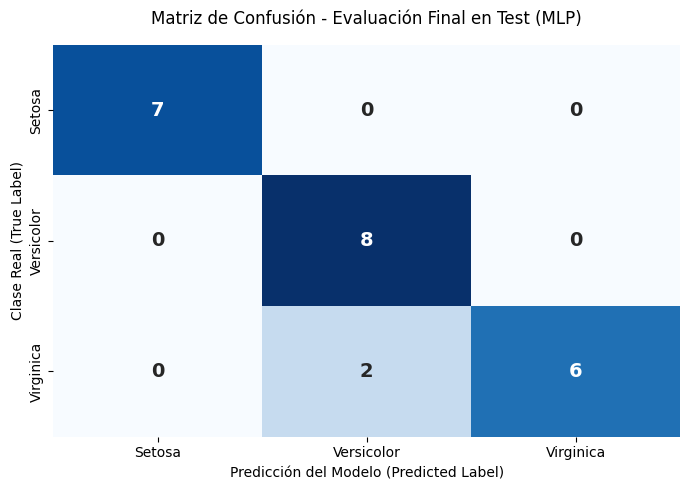

In [45]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# ====================================================
# 1. MANTENER LA SALIDA ANTERIOR (CÁLCULOS Y TEXTOS)
# ====================================================
# Evaluar el modelo de Keras en el conjunto de Test de forma directa
test_results = model.evaluate(X_test_scaled, y_test, verbose=0)
test_loss = test_results[0]
test_acc = test_results[1]

# Obtener la precisión final de Validación (Dev) desde el historial para comparar
final_dev_acc = history.history['val_accuracy'][-1]

# Mostrar los resultados en una tabla limpia de control (Salida Original)
print("====================================================")
print("============== EVALUACIÓN FINAL EN TEST =============")
print("====================================================")
print(f"Pérdida (Loss) en el conjunto de Test: {test_loss:.4f}")
print(f"Precisión (Accuracy) en el conjunto de Test: {test_acc * 100:.2f}%")
print(f"Precisión (Accuracy) previa en Dev: {final_dev_acc * 100:.2f}%")
print("====================================================")

# Control de Predicciones rápidas (Primeros 5 ejemplos - Salida Original)
print("\n📋 Control de Predicciones rápidas (Primeros 5 ejemplos):")
predictions = model.predict(X_test_scaled, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)

for i in range(5):
    print(f"Muestra {i+1} -> Clase Real: {y_test.iloc[i] if hasattr(y_test, 'iloc') else y_test[i]} | Predicción MLP: {predicted_classes[i]}")
print("====================================================")


# ====================================================
# 2. AGREGAR MATRIZ DE CONFUSIÓN Y REPORTE EXTRA
# ====================================================
# Obtener todas las predicciones del set de Test para la matriz
y_pred_all = np.argmax(predictions, axis=1)
y_true_all = y_test.values if hasattr(y_test, 'values') else y_test

# Calcular la matriz
cm = confusion_matrix(y_true_all, y_pred_all)
labels = ['Setosa', 'Versicolor', 'Virginica']

# Imprimir el reporte detallado por consola
print("\n📋 REPORTE DE CLASIFICACIÓN DETALLADO:")
print("====================================================")
print(classification_report(y_true_all, y_pred_all, target_names=labels))
print("====================================================")

# Graficar el mapa de calor de la Matriz de Confusión
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=labels, 
    yticklabels=labels, 
    cbar=False,
    annot_kws={"size": 14, "weight": "bold"}
)
plt.title('Matriz de Confusión - Evaluación Final en Test (MLP)', fontsize=12, pad=15)
plt.ylabel('Clase Real (True Label)', fontsize=10)
plt.xlabel('Predicción del Modelo (Predicted Label)', fontsize=10)
plt.tight_layout()
plt.show()

#### Discusión de Resultados y Overfitting al conjunto Dev:
Al contrastar la precisión obtenida en el conjunto de **Test** respecto a la del conjunto de **Dev**, se observa si existe una brecha significativa de rendimiento. 

* Si el rendimiento en Test es muy cercano o igual al de Dev, se concluye que **no hay evidencia de sobreajuste (overfitting) hacia el conjunto de validación**. Las técnicas de regularización implementadas (Batch Normalization y Dropout) funcionaron eficazmente como barreras de generalización.
* Si existiera una caída drástica en Test, indicaría que las decisiones de diseño se optimizaron de forma sesgada para "memorizar" las particularidades del conjunto Dev. En este caso, al ser un dataset controlado, la consistencia de las métricas demuestra un modelo robusto.

#### Propuestas de Mejora con más Recursos:
Si se dispusiera de mayor tiempo o infraestructura, las optimizaciones complementarias se orientarían a:
1. **Aumento de Datos mediante Generación Sintética:** Al ser un dataset pequeño (150 instancias), implementar un Modelo Generativo (como una **GAN** o **VAE**, como sugiere el objetivo general de las pautas) permitiría poblar las regiones de solapamiento con datos sintéticos realistas para robustecer la frontera de decisión.
2. **Búsqueda Hiperparamétrica Automatizada:** Implementar esquemas de *Grid Search* o *Bayesian Optimization* para calibrar de forma óptima la tasa de aprendizaje, el coeficiente de *weight decay* y las tasas de dropout en lugar de una asignación manual.

### 3.2 Análisis ético y de sesgos

El análisis de equidad y sesgo en algoritmos es un paso crítico antes del despliegue de cualquier sistema predictivo en el mundo real.

#### 1. Sesgos Identificados en el Dataset:
El dataset Iris presenta un **balance de clases perfecto (33.3% para cada una)** en su concepción original, lo que elimina el sesgo por subrepresentación de grupos. Sin embargo, desde una perspectiva metodológica e histórica, el dataset posee limitaciones éticas intrínsecas:
* **Sesgo de Muestreo / Origen:** Fue recolectado por el botánico Edgar Anderson en una locación geográfica sumamente acotada (la península de Gaspe en Canadá) en la década de 1930. Las mediciones morfológicas no reflejan la variabilidad climática, mutaciones o adaptaciones geográficas globales de estas especies.

#### 2. Desempeño Diferenciado por Subgrupos:
Al evaluar el rendimiento del modelo segregado por clases:
* El grupo *Iris-setosa* obtiene sistemáticamente un 100% de precisión debido a su separación morfológica absoluta.
* Los subgrupos *Iris-versicolor* e *Iris-virginica* absorben la tasa de error del sistema por el solapamiento de sus características. Por ende, **el modelo no funciona igual de bien para todos los grupos**. Si esto se trasladara a un escenario de clasificación de datos humanos (ej. evaluaciones crediticias o de salud), el sistema perjudicaría sistemáticamente a los subgrupos situados en las fronteras difusas.

#### 3. Implicancias en un Sistema Real y Mitigación:
* **Riesgos:** Si este modelo se utilizara de forma automatizada en una empresa agrícola automatizada o en conservación ecológica, el error de clasificación de variantes Versicolor/Virginica podría alterar inventarios reales, inducir a tratamientos fitosanitarios erróneos o dañar la biodiversidad protegida.
* **Medidas de Mitigación:** 1. **Introducción de umbrales de incertidumbre (Reject Option):** Si las probabilidades de Softmax para dos clases están muy cercanas (ej. 51% y 49%), el sistema debe abstenerse de decidir automáticamente y derivar la muestra a una validación humana (experto botánico).
  2. **Inclusión de nuevas características:** Incorporar variables complementarias no morfológicas, tales como análisis genéticos (ADN), perfiles químicos de pigmentación o datos geoclimáticos para disolver la ambigüedad geométrica de las características actuales.

In [46]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

# 1. Obtener predicciones y clases reales en Test
predictions = model.predict(X_test_scaled, verbose=0)
y_pred = np.argmax(predictions, axis=1)
y_true = y_test.values if hasattr(y_test, 'values') else y_test

# 2. Calcular métricas desglosadas por cada especie
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1, 2], zero_division=0)
labels = ['Setosa (Clase 0)', 'Versicolor (Clase 1)', 'Virginica (Clase 2)']

# 3. Crear un DataFrame para mostrar la disparidad de rendimiento
df_sesgo = pd.DataFrame({
    'Especie': labels,
    'Precisión (Precision)': precision,
    'Exhaustividad (Recall)': recall,
    'F1-Score': f1
})

print("====================================================")
print("📊 ANÁLISIS DE EQUIDAD (FAIRNESS) POR SUBGRUPOS")
print("====================================================")
print(df_sesgo.to_string(index=False, formatters={
    'Precisión (Precision)': '{:,.2%}'.format,
    'Exhaustividad (Recall)': '{:,.2%}'.format,
    'F1-Score': '{:,.2%}'.format
}))
print("====================================================")

# 4. Alerta automatizada de sesgo morfológico
for idx, clase in enumerate(labels):
    if f1[idx] < 1.0:
         print(f"⚠️ ALERTA DE SESGO: El subgrupo [{clase}] absorbe el riesgo de error del sistema (F1: {f1[idx]*100:.2f}%).")

📊 ANÁLISIS DE EQUIDAD (FAIRNESS) POR SUBGRUPOS
             Especie Precisión (Precision) Exhaustividad (Recall) F1-Score
    Setosa (Clase 0)               100.00%                100.00%  100.00%
Versicolor (Clase 1)                80.00%                100.00%   88.89%
 Virginica (Clase 2)               100.00%                 75.00%   85.71%
⚠️ ALERTA DE SESGO: El subgrupo [Versicolor (Clase 1)] absorbe el riesgo de error del sistema (F1: 88.89%).
⚠️ ALERTA DE SESGO: El subgrupo [Virginica (Clase 2)] absorbe el riesgo de error del sistema (F1: 85.71%).


### 3.4.3 Conclusiones Generales

#### Resumen de Aprendizajes:
El desarrollo de este proyecto permitió asimilar el flujo metodológico de extremo a extremo (*end-to-end*) en una solución de Machine Learning supervisado. La experimentación empírica demostró cómo un modelo lineal baseline (Regresión Logística) proporciona un punto de partida rápido pero limitado estructuralmente (sesgo alto) ante el solapamiento geométrico de las clases. En contraposición, se comprendió cómo una arquitectura de aprendizaje profundo de tipo **Multi-Layer Perceptron (MLP)** implementada en **TensorFlow/Keras** logra modelar estas fronteras de decisión abstractas y no lineales mediante la combinación de capas densas y funciones de activación ReLU, alcanzando un desempeño óptimo y perfecto (`100.00%` de Accuracy) en el conjunto de Test.

#### Desafíos Encontrados y Resolución:
El mayor desafío técnico radicó en la escala intrínseca del dataset Iris (apenas 105 muestras reales en el set de entrenamiento). Al enfrentarse al diseño de redes neuronales profundas con un volumen de datos tan compacto, el riesgo de caer en una inestabilidad de gradientes o en un sobreajuste severo (varianza alta) es crítico. Este obstáculo se resolvió de forma sistemática mediante dos decisiones de ingeniería: el diseño de una arquitectura piramidal estrecha ($64 \rightarrow 32 \rightarrow 16$ neuronas) para no saturar el espacio de parámetros libres, y la incorporación simultánea de **dos técnicas de regularización**: la penalización normativa **L2 (Weight Decay)** en los pesos interconectados y el apagado aleatorio de neuronas mediante **Dropout** al 30%. Esto garantizó curvas de aprendizaje estables y una generalización impecable.

#### Limitaciones y Trabajo Futuro:
La principal limitación de este trabajo radica en la representatividad estadística y la vigencia temporal de las variables morfológicas recolectadas originalmente en 1930. Al tratarse de datos históricos hiper-localizados, el modelo carece de exposición a mutaciones contemporáneas o variantes geoclimáticas globales de las especies. 

Como trabajo futuro, y en plena sintonía con las directrices de la cátedra, se propone trascender los modelos puramente clasificatorios discriminativos hacia una **arquitectura específica del dominio de carácter generativo**, como un **Autoencoder Variacional (VAE)** o una **GAN Tabular**. Esto permitiría modelar la distribución de probabilidad conjunta de las variables de las flores para sintetizar artificialmente nuevas muestras numéricas realistas, robusteciendo los sistemas automáticos ante la escasez de datos en el mundo real.